In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, Conv1D, BatchNormalization, Dropout,
    TimeDistributed, Flatten, Normalization, Rescaling
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [60]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['sensor_{}'.format(i) for i in range(1,22)]
col_names = index_names + setting_names + sensor_names

In [87]:
path = '/content/drive/MyDrive/Project Dataset/MTP Dataset/'
df_train = pd.read_csv(path+'train_FD004.txt',sep='\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv(path+'test_FD004.txt',sep='\s+',header=None,index_col=False,names=col_names)
y_test = pd.read_csv(path+'RUL_FD004.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
y_test.shape

(248, 1)

In [88]:
train = df_train.copy()
test = df_test.copy()
print('Shape of the train dataset : ',train.shape)
print('Shape of the test dataset : ',test.shape)

Shape of the train dataset :  (61249, 26)
Shape of the test dataset :  (41214, 26)


In [89]:
display(train)
display(test)

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,...,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,...,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,...,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,...,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,...,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41209,248,277,41.9991,0.8401,100.0,445.00,550.30,1364.40,1129.17,3.91,...,130.87,2388.50,8112.61,9.4427,0.02,331,2212,100.00,10.53,6.2620
41210,248,278,20.0026,0.7005,100.0,491.19,608.00,1494.75,1260.88,9.35,...,314.51,2388.33,8086.83,9.2772,0.02,366,2324,100.00,24.33,14.6486
41211,248,279,34.9988,0.8413,100.0,449.44,555.92,1370.65,1130.97,5.48,...,182.76,2388.64,8100.84,9.3982,0.02,336,2223,100.00,14.69,8.8389
41212,248,280,20.0027,0.7000,100.0,491.19,608.19,1489.11,1256.25,9.35,...,314.17,2388.37,8085.24,9.2727,0.03,366,2324,100.00,24.44,14.6887


In [90]:
def process_targets(data_length, early_rul):
  early_rul_duration = data_length - early_rul
  if early_rul_duration <= 0:
    return np.arange(data_length-1, -1, -1)
  else:
    new_early_rul = early_rul * np.ones(early_rul_duration)
    origin_rul = np.arange(early_rul-1, -1, -1)
    return np.append(new_early_rul,origin_rul)

In [91]:
def process_input_data_with_targets(input_data, target_data, window_length, shift):
    # Number of batches
    num_batches = int(np.floor((len(input_data) - window_length) / shift)) + 1
    num_features = input_data.shape[1]  # Number of features per sample

    # Prepare output array
    output = np.repeat(np.nan, repeats=num_batches * window_length * num_features)
    output_data = output.reshape(num_batches, window_length, num_features)

    if target_data is None:  # Test data without target
        for batch in range(num_batches):
            start_idx = shift * batch
            end_idx = start_idx + window_length
            output_data[batch, :, :] = input_data[start_idx:end_idx, :]
        return output_data
    else:  # Training data with targets
        output_targets = np.repeat(np.nan, repeats=num_batches)  # target RUL
        for batch in range(num_batches):
            window_start = shift * batch
            window_end = window_start + window_length

            output_data[batch, :, :] = input_data[window_start:window_end, :]
            output_targets[batch] = target_data[window_end - 1]
        return output_data, output_targets


In [92]:
def process_test_data(test_data_for_an_engine, window_length, shift, num_test_windows=1):
    T = len(test_data_for_an_engine)

    # ===== FD002 SAFETY GUARD =====
    if T < window_length:
        pad_len = window_length - T
        pad = np.repeat(test_data_for_an_engine[:1, :], pad_len, axis=0)
        test_data_for_an_engine = np.vstack((pad, test_data_for_an_engine))
        T = len(test_data_for_an_engine)
    # ==============================

    max_num_test_batches = int(np.floor((T - window_length) / shift)) + 1

    if max_num_test_batches < num_test_windows:
        required_len = (max_num_test_batches - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(
            test_data_for_an_engine[-required_len:, :],
            target_data=None,
            window_length=window_length,
            shift=shift
        )
        return batched_test_data_for_an_engine, max_num_test_batches
    else:
        required_len = (num_test_windows - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(
            test_data_for_an_engine[-required_len:, :],
            target_data=None,
            window_length=window_length,
            shift=shift
        )
        return batched_test_data_for_an_engine, num_test_windows


In [93]:
train_data_first_column = train["unit_number"]
test_data_first_column = test["unit_number"]

scaler = MinMaxScaler()

train_data = scaler.fit_transform(
    train.drop(columns=['unit_number'] + setting_names)
)

test_data = scaler.transform(
    test.drop(columns=['unit_number'] + setting_names)
)

train_data = pd.DataFrame(
    data=np.c_[train_data_first_column, train_data]
)

test_data = pd.DataFrame(
    data=np.c_[test_data_first_column, test_data]
)

num_train_machines = train_data[0].nunique()
num_test_machines = test_data[0].nunique()


In [94]:
window_length = 30
shift = 1
early_rul = 125
num_test_windows = 5

In [95]:
processed_train_data = []
processed_train_targets = []

# Use Python int instead of np.int
for i in np.arange(1, num_train_machines + 1, dtype=int):
    # Get data for one machine
    temp_train_data = train_data[train_data[0] == i].drop(columns=[0]).values

    # Generate targets
    temp_train_targets = process_targets(data_length=temp_train_data.shape[0], early_rul=early_rul)

    # Process input data with targets
    data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(
        temp_train_data, temp_train_targets, window_length=window_length, shift=shift
    )

    # Append to lists
    processed_train_data.append(data_for_a_machine)
    processed_train_targets.append(targets_for_a_machine)

# Concatenate all machines' data
processed_train_data = np.concatenate(processed_train_data)
processed_train_targets = np.concatenate(processed_train_targets)


In [96]:
processed_test_data = []
num_test_windows_list = []

for i in np.arange(1, num_test_machines + 1):
    temp_test_data = test_data[test_data[0] == i].drop(columns = [0]).values

    # Prepare test data
    test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length=window_length, shift = shift,num_test_windows = num_test_windows)

    processed_test_data.append(test_data_for_an_engine)
    num_test_windows_list.append(num_windows)

processed_test_data = np.concatenate(processed_test_data)
true_rul = y_test.values

# Shuffle training data
index = np.random.permutation(len(processed_train_targets))
processed_train_data, processed_train_targets = processed_train_data[index], processed_train_targets[index]

In [97]:
print("Processed trianing data shape: ", processed_train_data.shape)
print("Processed training ruls shape: ", processed_train_targets.shape)
print("Processed test data shape: ", processed_test_data.shape)
print("True RUL shape: ", true_rul.shape)

Processed trianing data shape:  (54028, 30, 22)
Processed training ruls shape:  (54028,)
Processed test data shape:  (1196, 30, 22)
True RUL shape:  (248, 1)


In [98]:

processed_train_data, processed_val_data, processed_train_targets, processed_val_targets = train_test_split(processed_train_data,
                                                        processed_train_targets,
                                                        test_size = 0.2,
                                                        random_state = 666)
print("Processed train data shape: ", processed_train_data.shape)
print("Processed validation data shape: ", processed_val_data.shape)
print("Processed train targets shape: ", processed_train_targets.shape)
print("Processed validation targets shape: ", processed_val_targets.shape)

Processed train data shape:  (43222, 30, 22)
Processed validation data shape:  (10806, 30, 22)
Processed train targets shape:  (43222,)
Processed validation targets shape:  (10806,)


In [99]:
num_features = processed_train_data.shape[2]
print("Number of features:", num_features)
window_length = processed_train_data.shape[1]
num_features  = processed_train_data.shape[2]

print(window_length, num_features)
# → 30 22   (FD002, all sensors)


Number of features: 22
30 22


In [100]:
from tensorflow.keras import layers, Model, Input
import tensorflow as tf

def Autoencoder_BiLSTM_model(window_length=30, num_features=15, latent_dim=64):
    """
    Autoencoder + Bi-LSTM model
    Args:
        window_length : number of time steps per sequence
        num_features  : number of sensor features per time step
        latent_dim    : size of latent vector from encoder
    Returns:
        Compiled Keras Model
    """

    # --------------------
    # Encoder (Autoencoder part)
    # --------------------
    inputs = Input(shape=(window_length, num_features))

    # Encoder
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Flatten to get latent vector
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_vector')(x)

    # --------------------
    # Repeat vector for LSTM
    # --------------------
    x = layers.RepeatVector(window_length)(latent)

    # --------------------
    # Bi-LSTM for sequence modeling
    # --------------------
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, activation='tanh'))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, activation='tanh'))(x)
    x = layers.Bidirectional(layers.LSTM(32, activation='tanh'))(x)

    # Fully connected layers for final regression
    x = layers.Dense(96, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(1, name='rul_output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Autoencoder_BiLSTM')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    return model

# Example usage
ae_bi_lstm_model = Autoencoder_BiLSTM_model(
    window_length=window_length,
    num_features=num_features,
    latent_dim=64
)

ae_bi_lstm_model.summary()



Model: "Autoencoder_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 30, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 30, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_9 (RepeatVector)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_27                │ (None, 30, 256)        │       197,632 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_28                │ (None, 30, 128)        │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_29                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 508,385 (1.94 MB)

 Trainable params: 508,385 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
def scheduler(epoch):
  if epoch < 10:
    return 0.001
  else:
    return 0.0001

In [102]:
tf_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")
callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose = 0)
batch_size = 50
epoch = 40
kernel_size = 3
pool_size = 2

# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1,patience=4, min_lr=1e-7, verbose=1)

In [103]:
model_history = ae_bi_lstm_model.fit(
    processed_train_data,
    processed_train_targets,
    epochs=epoch,
    validation_data=(processed_val_data, processed_val_targets),
    callbacks=[tf_callback, callback],
    batch_size=batch_size,
    verbose=1
)

# Keep it in a models dictionary for consistency
models = {"AE+Bi-LSTM": ae_bi_lstm_model}


Epoch 1/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 2436.7983 - val_loss: 518.8256 - learning_rate: 0.0010
Epoch 2/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 551.2892 - val_loss: 426.0782 - learning_rate: 0.0010
Epoch 3/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 459.3628 - val_loss: 425.8736 - learning_rate: 0.0010
Epoch 4/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 399.5516 - val_loss: 361.3818 - learning_rate: 0.0010
Epoch 5/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 360.1349 - val_loss: 341.0827 - learning_rate: 0.0010
Epoch 6/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 325.8615 - val_loss: 313.2151 - learning_rate: 0.0010
Epoch 7/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 293.8272 - val_loss: 340.0334 - learning_rate: 0.0010
Epoch 8/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 245.3516 - val_loss: 240.5931 - learning_rate: 0.0010
Epoch 9/40
865/865 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 225.1183 

In [104]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # PHM score
    d = y_pred - y_true
    phm_score = np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

    print(f"=== {model_name} Evaluation ===")
    print(f"MSE        : {mse:.4f}")
    print(f"RMSE       : {rmse:.4f}")
    print(f"MAE        : {mae:.4f}")
    print(f"R²         : {r2:.4f}")
    print(f"PHM Score  : {phm_score:.4f}")

In [105]:
# ===================== FD002-CORRECT EVALUATION =====================

# Predict on test data
rul_pred = ae_bi_lstm_model.predict(processed_test_data, verbose=0).reshape(-1)

# Split predictions per engine using number of windows
preds_for_each_engine = np.split(
    rul_pred,
    np.cumsum(num_test_windows_list)[:-1]
)

# FD002 RULE: use ONLY the LAST window prediction per engine
last_pred_for_each_engine = np.array([
    preds[-1] for preds in preds_for_each_engine
])

# Print final training losses
print('Training loss  :', model_history.history['loss'][-1])
print('Validation loss:', model_history.history['val_loss'][-1])

# Ground truth RUL
y_true = y_test.values.flatten()

# Sanity check (must match)
print("Pred shape:", last_pred_for_each_engine.shape)
print("True shape:", y_true.shape)

assert len(last_pred_for_each_engine) == len(y_true), "Prediction–label length mismatch!"

# Evaluate
evaluate(
    y_true,
    last_pred_for_each_engine,
    model_name="AE + Bi-LSTM"
)

# ================================================================


Training loss  : 42.767398834228516
Validation loss: 102.85674285888672
Pred shape: (248,)
True shape: (248,)
=== AE + Bi-LSTM Evaluation ===
MSE        : 1169.3615
RMSE       : 34.1959
MAE        : 25.2643
R²         : 0.6067
PHM Score  : 47688.2889


In [106]:
print("Training sequences:", processed_train_data.shape)
print("Validation sequences:", processed_val_data.shape)
print("Test sequences:", processed_test_data.shape)
print("True RULs:", true_rul.shape)

Training sequences: (43222, 30, 22)
Validation sequences: (10806, 30, 22)
Test sequences: (1196, 30, 22)
True RULs: (248, 1)


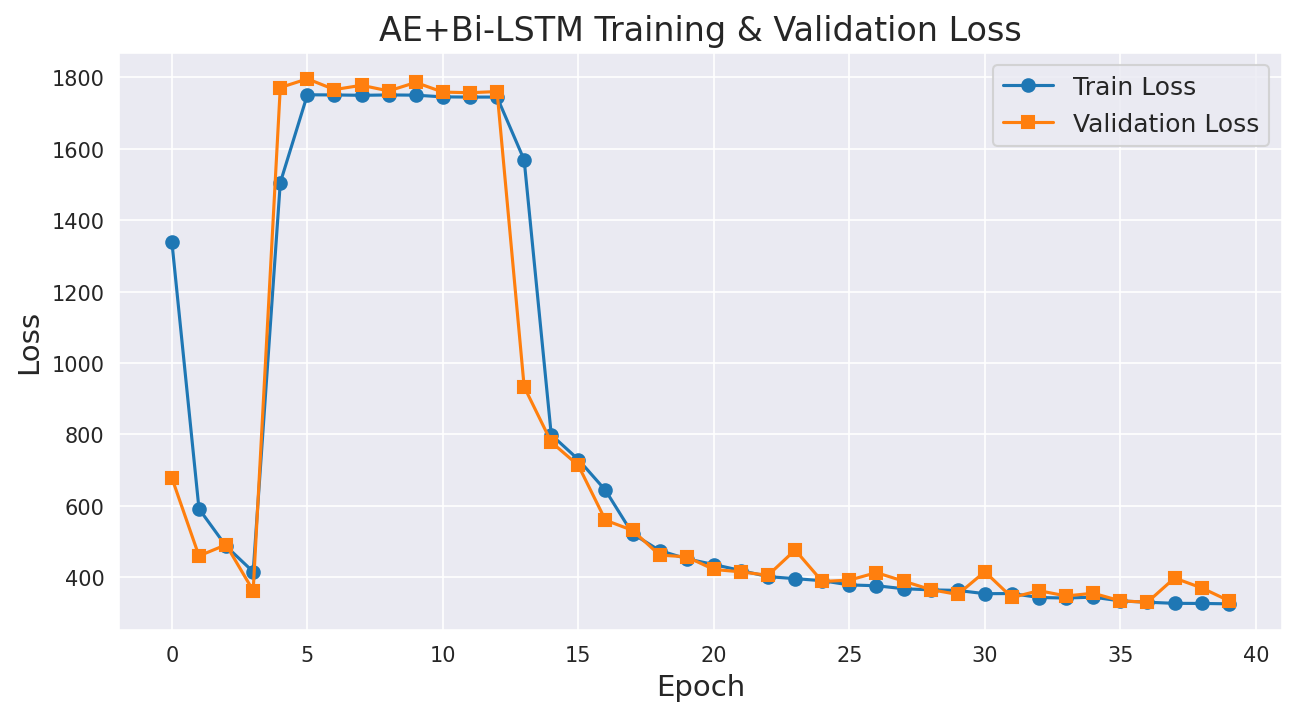

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')  # options: 'whitegrid', 'darkgrid', 'ticks', etc.

# Plot Bi-LSTM training & validation loss
plt.figure(figsize=(10, 5), dpi=150)

plt.plot(history_train_loss[0], label='Train Loss', marker='o')
plt.plot(history_val_loss[0], label='Validation Loss', marker='s')

plt.title('AE+Bi-LSTM Training & Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_predActual(y_test, y_predictions, model_name):
    y_test = np.array(y_test).flatten()
    y_predictions = np.array(y_predictions).flatten()

    plt.style.use('seaborn-white')
    plt.figure(figsize=(20, 5))
    plt.title(f'{model_name} Prediction Results', fontsize=16)
    plt.xlabel('Test Engine', fontsize=16)
    plt.ylabel('RUL', fontsize=16)

    sns.lineplot(x=np.arange(len(y_test)), y=y_test, color='lightseagreen', label='Actual')
    sns.lineplot(x=np.arange(len(y_predictions)), y=y_predictions, color='salmon', label='Predicted')

    plt.grid(True)
    plt.legend(fontsize=12)
    plt.show()


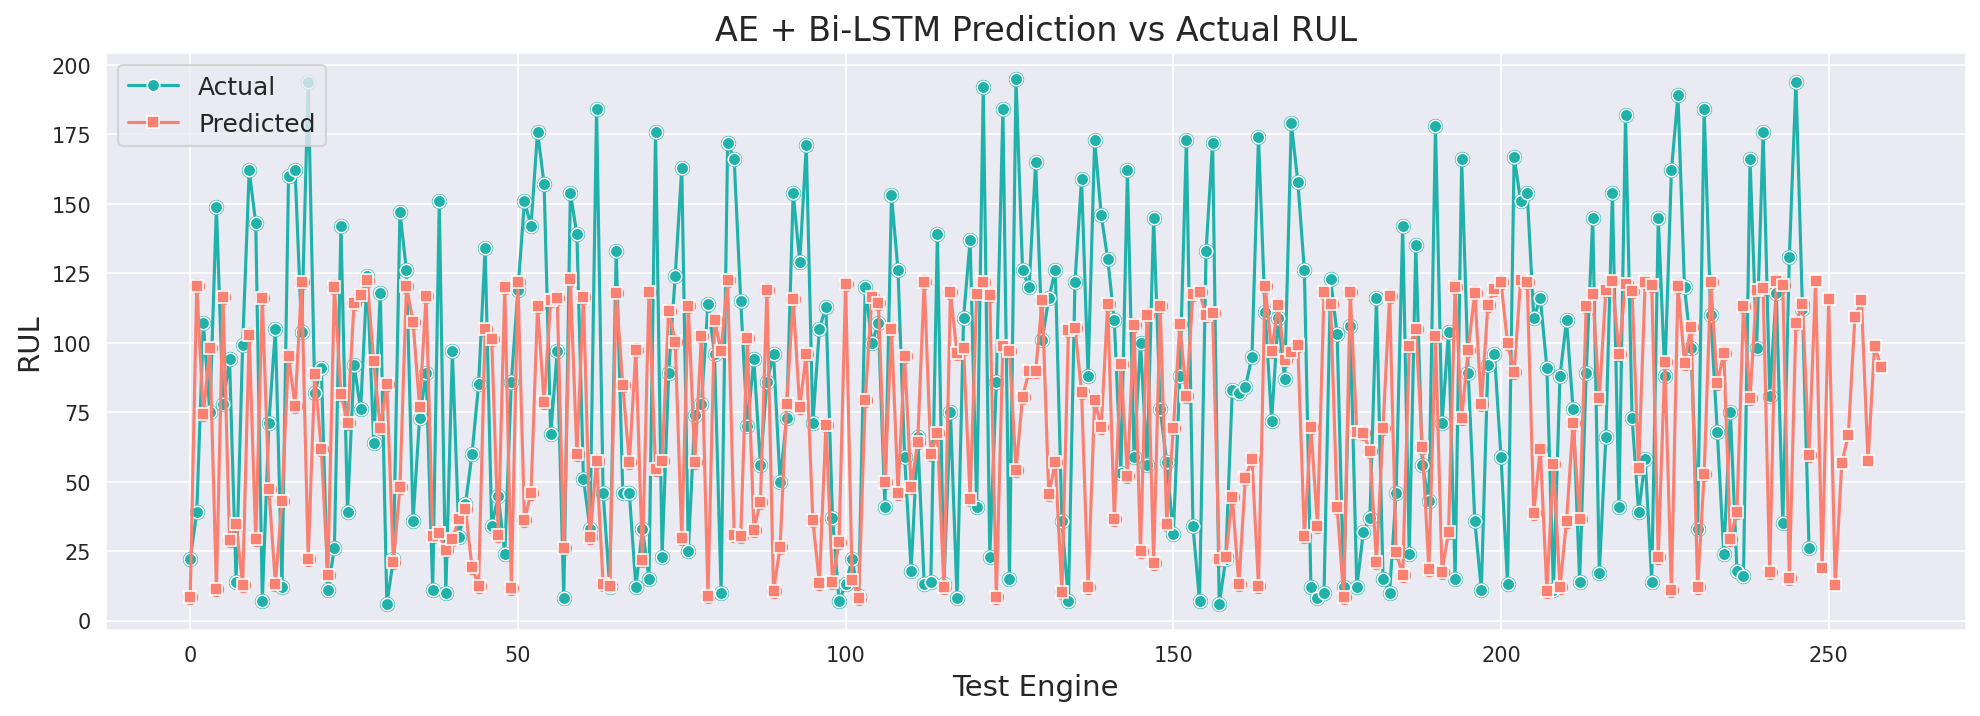

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_predActual(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    sns.set_style('darkgrid')  # Seaborn style

    plt.figure(figsize=(16, 5), dpi=150)
    plt.title(f'{model_name} Prediction vs Actual RUL', fontsize=16)
    plt.xlabel('Test Engine', fontsize=14)
    plt.ylabel('RUL', fontsize=14)

    # Plot actual and predicted RUL with markers
    sns.lineplot(x=np.arange(len(y_true)), y=y_true, color='lightseagreen', label='Actual', marker='o')
    sns.lineplot(x=np.arange(len(y_pred)), y=y_pred, color='salmon', label='Predicted', marker='s')

    # Optional: mark each engine explicitly
    for i in range(len(y_true)):
        plt.scatter(i, y_true[i], color='lightseagreen', s=40)  # actual
        plt.scatter(i, y_pred[i], color='salmon', s=40)         # predicted

    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

# Define y_true from test RULs
y_true = true_rul.flatten()

# Plot using your predicted RULs
plot_predActual(y_true, mean_pred_for_each_engine, "AE + Bi-LSTM")
